# Imports

### Solving moabb dependency problem

In [1]:
import moabb.datasets
try:
    from moabb.datasets import BNCI2014_001
    moabb.datasets.BNCI2014001 = BNCI2014_001
except ImportError:
    pass

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd

from sklearn.metrics import balanced_accuracy_score,confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from skorch.callbacks import LRScheduler
from skorch.callbacks import EarlyStopping
from skorch.helper import predefined_split
from skorch.dataset import ValidSplit

import mne
from braindecode import EEGClassifier
from braindecode.datasets import BaseConcatDataset, BaseDataset
from braindecode.models import EEGNet
from braindecode.util import set_random_seeds
from braindecode.datautil import load_concat_dataset

import torch

# Loading Data

In [4]:
windows_dataset = load_concat_dataset('preprocessing/eegnet_ner_processed', preload=True)
splitted = windows_dataset.split("subject")
subjects_list = list(splitted.keys())

Reading c:\Users\oskik\_0_My_folder\Magisterka\kod_classification_model\preprocessing\eegnet_ner_processed\0\0-epo.fif ...
Isotrak not found
    Found the data of interest:
        t =    -203.12 ...     703.12 ms
        0 CTF compensation matrices available
Adding metadata with 4 columns
7 matching events found
No baseline correction applied
0 projection items activated


TypeError: 'NoneType' object is not iterable

# Model

### CUDA

In [4]:
cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = "cuda" if cuda else "cpu"
if cuda:
    torch.backends.cudnn.benchmark = True
seed = 42
set_random_seeds(seed=seed, cuda=cuda)


n_classes = 2
classes = list(range(n_classes))
# Extract number of chans and time steps from dataset
n_channels = windows_dataset[0][0].shape[0]
n_times = windows_dataset[0][0].shape[1]

c:\Users\oskik\anaconda3\envs\cm\lib\site-packages\braindecode\util.py:52: UserWarning: torch.backends.cudnn.benchmark was set to True which may results in lack of reproducibility. In some cases to ensure reproducibility you may need to set torch.backends.cudnn.benchmark to False.
  warn(


### EEGNet

In [5]:
model = EEGNet(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,
    drop_prob=0.5
)

print(model)

if cuda:
    model.cuda()

Layer (type (var_name):depth-idx)                            Input Shape               Output Shape              Param #                   Kernel Shape
EEGNet (EEGNet)                                              [1, 64, 63]               [1, 2]                    --                        --
├─Ensure4d (ensuredims): 1-1                                 [1, 64, 63]               [1, 64, 63, 1]            --                        --
├─Rearrange (dimshuffle): 1-2                                [1, 64, 63, 1]            [1, 1, 64, 63]            --                        --
├─Conv2d (conv_temporal): 1-3                                [1, 1, 64, 63]            [1, 8, 64, 64]            512                       [1, 64]
├─BatchNorm2d (bnorm_temporal): 1-4                          [1, 8, 64, 64]            [1, 8, 64, 64]            16                        --
├─ParametrizedConv2dWithConstraint (conv_spatial): 1-5       [1, 8, 64, 64]            [1, 16, 1, 64]            --                  

### Classifier

In [6]:
lr = 0.0001
batch_size = 64
n_epochs = 250
train_percent = 0.8

clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    optimizer__lr=lr,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        "balanced_accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs
)


In [7]:
early_stopping = EarlyStopping(
    monitor='valid_loss',
    patience=10,
    lower_is_better=True,
    load_best=True
)

# Within-subject

In [ ]:
results_within = []
learning_histories = {}

for subject in subjects_list:
    print(f"Trening modelu dla pacjenta {subject}...")

    subj_sessions = splitted[subject].split('session')
    session_keys = sorted(subj_sessions.keys(), key=int)

    split_idx = int(len(session_keys) * train_percent)
    train_keys = session_keys[:split_idx]
    test_keys = session_keys[split_idx:]

    train_set = BaseConcatDataset([subj_sessions[k] for k in train_keys])
    test_set = BaseConcatDataset([subj_sessions[k] for k in test_keys])

    print(f"Zbiór treningowy: {len(train_set)} epok (sesje {train_keys[0]}-{train_keys[-1]})")
    print(f"Zbiór testowy: {len(test_set)} epok (sesje {test_keys[0]}-{test_keys[-1]})")

    y_train = [y for _, y, _ in train_set] 
    class_counts = np.bincount(y_train) 
    total_samples = len(y_train)

    w0 = total_samples / (2 * class_counts[0]) 
    w1 = total_samples / (2 * class_counts[1]) 
    weights = torch.tensor([w0, w1], dtype=torch.float).to(device)

    clf.set_params(
        criterion__weight=weights,
        train_split=ValidSplit(cv=0.2),
        callbacks=[early_stopping],
        optimizer__weight_decay=0.02
    )

    clf.fit(train_set, y=None)   

    learning_histories[subject] = {
        'train_loss': clf.history[:, 'train_loss'],
        'valid_loss': clf.history[:, 'valid_loss']
    }

    y_pred = clf.predict(test_set)
    y_true = [y for _, y, _ in test_set]
    
    for true_val, pred_val in zip(y_true, y_pred):
        results_within.append({'subject': subject, 'y_true': true_val, 'y_pred': pred_val})

Trening modelu dla pacjenta 1...
Zbiór treningowy: 816 epok (sesje 0-15)
Zbiór testowy: 228 epok (sesje 16-19)
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.7335       0.6037        0.6952  2.4416
      2        0.7140       0.6402        0.6945  0.4709
      3        0.7264       0.6768        0.6936  0.4190
      4        0.7058       0.6890        0.6924  0.4170
      5        0.6977       0.7256        0.6909  0.4880
      6        0.6833       0.7561        0.6893  0.4727
      7        0.6602       0.7683        0.6874  0.4740
      8        0.6803       0.7866        0.6854  0.4610
      9        0.6563       0.7866        0.6833  0.4465
     10        0.6550       0.7805        0.6810  0.4490
     11        0.6425       0.7683        0.6784  0.4371
     12        0.6380       0.7744        0.6754  0.4154
     13        0.6472       0.7683        0.6724  0.4216
     14        0.6349       0.7683

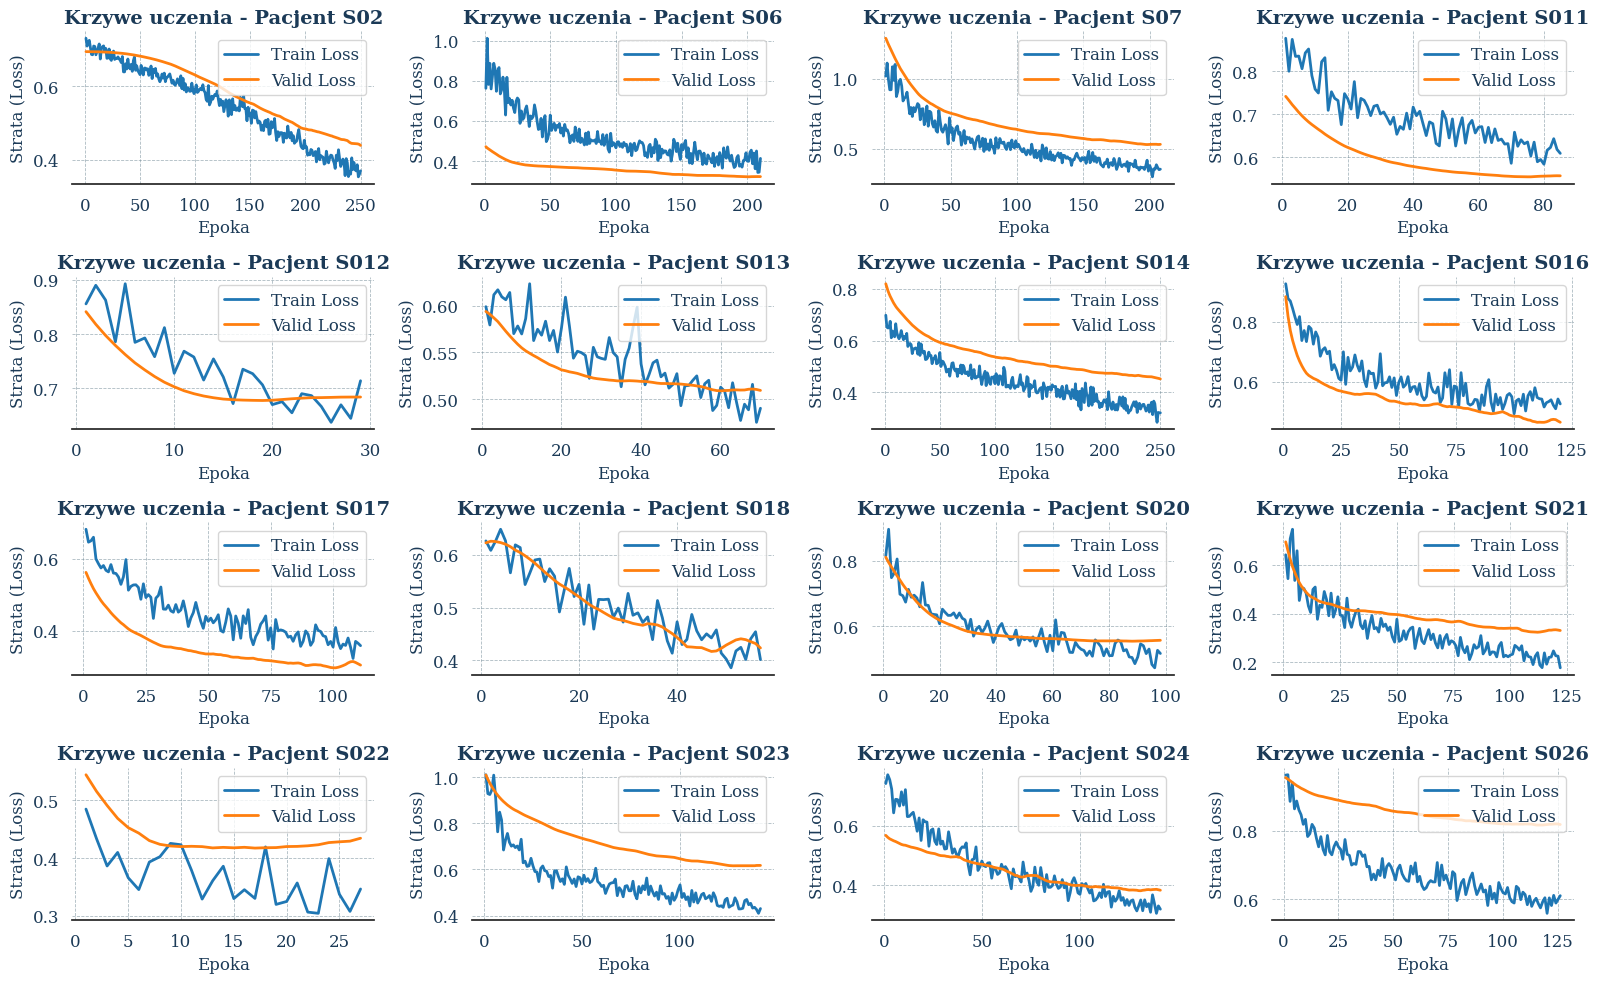

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
axes = axes.flatten()

for idx, subject in enumerate(subjects_list):
    ax = axes[idx]
    train_loss = learning_histories[subject]['train_loss']
    valid_loss = learning_histories[subject]['valid_loss']
    epochs = range(1, len(train_loss) + 1)
    
    # Rysowanie linii
    ax.plot(epochs, train_loss, label='Train Loss', color='#1f77b4', linewidth=2)
    ax.plot(epochs, valid_loss, label='Valid Loss', color='#ff7f0e', linewidth=2)
    
    # Formatowanie pojedynczego wykresu
    ax.set_title(f'Krzywe uczenia - Pacjent S0{subject}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoka', fontsize=12)
    ax.set_ylabel('Strata (Loss)', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Cross-subject

In [17]:
results_cross = []

for subject in subjects_list:
    print(f"Trening modelu dla pacjenta {subject}...")

    train_datasets = []

    for sub_id in subjects_list:
        if sub_id == subject:
            # Ten pacjent to nasz hermetyczny zbiór testowy
            test_set = splitted[sub_id]
        else:
            # Pozostali pacjenci idą do wspólnego zbioru treningowego
            train_datasets.append(splitted[sub_id])

    train_set = BaseConcatDataset(train_datasets)

    print(f"Zbiór treningowy: {len(train_set)} epok (pacjenci {', '.join([s for s in subjects_list if s != subject])})")
    print(f"Zbiór testowy: {len(test_set)} epok (pacjent {subject})")

    y_train = [y for _, y, _ in train_set] 
    class_counts = np.bincount(y_train) 
    total_samples = len(y_train)

    w0 = total_samples / (2 * class_counts[0]) 
    w1 = total_samples / (2 * class_counts[1]) 
    weights = torch.tensor([w0, w1], dtype=torch.float).to(device)

    clf.set_params(
        criterion__weight=weights,
        train_split=ValidSplit(cv=0.2),
        callbacks=[early_stopping],
        optimizer__weight_decay=0.01
    )

    clf.fit(train_set, y=None)   

    y_pred = clf.predict(test_set)
    y_true = [y for _, y, _ in test_set]
    
    for true_val, pred_val in zip(y_true, y_pred):
        results_cross.append({'subject': subject, 'y_true': true_val, 'y_pred': pred_val})

Trening modelu dla pacjenta 1...
Zbiór treningowy: 5393 epok (pacjenci 2, 3, 4, 5, 6)
Zbiór testowy: 1044 epok (pacjent 1)
Re-initializing criterion because the following parameters were re-set: criterion__weight.
Re-initializing optimizer.
Re-initializing module.
Re-initializing criterion because the following parameters were re-set: weight.
Re-initializing optimizer.
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.4606       0.7822        0.4323  3.3002
      2        0.4219       0.7868        0.4243  3.0836
      3        0.4017       0.8137        0.4068  2.9836
      4        0.3952       0.8109        0.4133  2.9990
      5        0.3880       0.8193        0.4103  3.0333
      6        0.3732       0.8295        0.4016  3.3037
      7        0.3787       0.8128        0.4043  3.4235
      8        0.3731       0.8239        0.4092  3.5995
      9        0.3612       0.8091        0.4047  3.7386
 

# Results

In [104]:
df_results_within = pd.DataFrame(results_within)
#df_results_cross = pd.DataFrame(results_cross)

### Save to CSV

In [ ]:
pd.DataFrame(df_results_within).to_csv("eegnet_ner/results_within.csv", index=False)
#pd.DataFrame(df_results_cross).to_csv("eegnet_ner/results_cross.csv", index=False)

## Wizki

In [ ]:
df_within = pd.read_csv("eegnet_ner/results_within.csv")
df_cross = pd.read_csv("eegnet_ner/results_cross.csv")
results_table = []

### Metrics function

In [ ]:
def calculate_metrics(df, experiment_name):
    results_table = []

    for subject, group in df.groupby('subject'):
        y_true = group['y_true']
        y_pred = group['y_pred']
        
        acc = balanced_accuracy_score(y_true, y_pred) * 100
        f1 = f1_score(y_true, y_pred, pos_label=0)
        precision = precision_score(y_true, y_pred, pos_label=0)
        recall = recall_score(y_true, y_pred, pos_label=0)
        
        results_table.append({
            'Experiment': experiment_name,
            'Patient': f"{subject}",
            'Balanced Accuracy (%)': round(acc, 2),
            'F1-Score (ErrP)': round(f1, 3),
            'Precision (ErrP)': round(precision, 3),
            'Recall (ErrP)': round(recall, 3)
        })
    
    return results_table

In [ ]:
results_within = calculate_metrics(df_within, 'Within-Subject')
#results_cross = calculate_metrics(df_cross, 'Cross-Subject')
#combined_results = results_within + results_cross
#df_results = pd.DataFrame(combined_results)
df_results = pd.DataFrame(results_within)

In [ ]:
print("--- RESULTS TABLE ---")
print(df_results.to_string(index=False))

--- TABELA ZBIORCZA WYNIKÓW ---
    Experiment Patient  Balanced Accuracy (%)  F1-Score (ErrP)  Precision (ErrP)  Recall (ErrP)
Within-Subject     S02                  68.10            0.605             0.719          0.523
Within-Subject     S06                  68.34            0.333             0.226          0.636
Within-Subject     S07                  78.03            0.435             0.294          0.833
Within-Subject     S11                  56.66            0.579             0.492          0.705
Within-Subject     S12                  53.53            0.444             0.645          0.339
Within-Subject     S13                  77.00            0.753             0.814          0.700
Within-Subject     S14                  64.00            0.633             0.646          0.620
Within-Subject     S16                  59.86            0.574             0.574          0.574
Within-Subject     S17                  80.45            0.773             0.723          0.829
Within-S

In [ ]:
pd.DataFrame(df_results.to_csv("eegnet_ner/results.csv", index=False))

""


### Confusion matrices

In [ ]:
def plot_confusion_matrices(df, experiment_name, filename):
    fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(16, 10))
    axes = axes.flatten()
    
    subjects_list = sorted(df['subject'].unique())
    
    for i, sub_id in enumerate(subjects_list):
        ax = axes[i]
        
        sub_data = df[df['subject'] == sub_id]
        y_true = sub_data['y_true']
        y_pred = sub_data['y_pred']
        
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BŁĄD', 'Poprawne'])
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        
        ax.set_title(f"Pacjent S{int(sub_id):02d}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Przewidziana klasa')
        ax.set_ylabel('Prawdziwa klasa')
    
    plt.suptitle(f"Macierze Pomyłek - {experiment_name}", fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

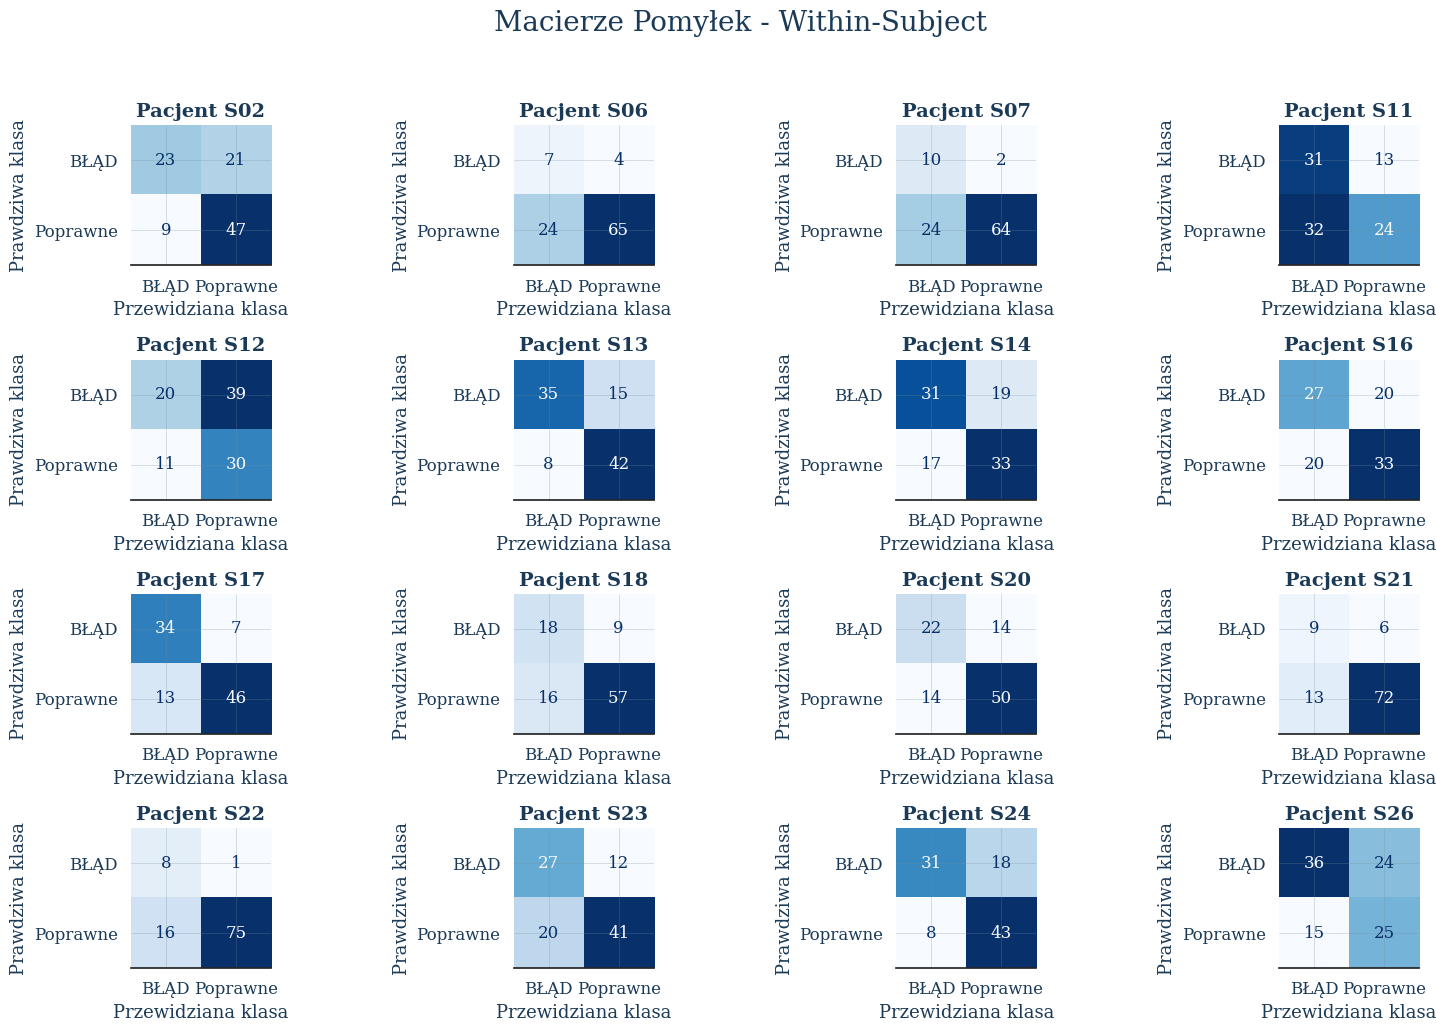

In [112]:
plot_confusion_matrices(df_within, 'Within-Subject', 'EEG_Within_Subject.png')
#plot_confusion_matrices(df_cross, 'Cross-Subject', 'EEG_Cross_Subject.png')

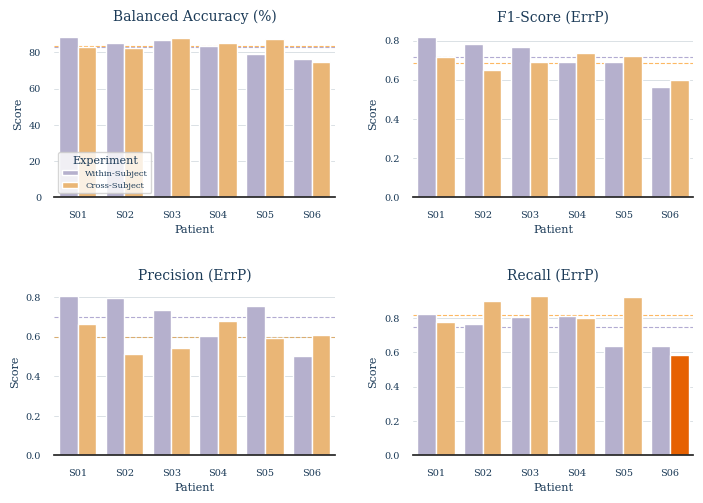

In [ ]:
# Create subplots for each metric
df = pd.read_csv("eegnet_ner/results.csv")
metrics = df.columns[2:]
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

target_bar_index = 11
chosen_hex_color = "#e66101"

for i, metric in enumerate(metrics):
    sns.barplot(data=df, x='Patient', y=metric, hue='Experiment', ax=axes[i], palette=['#b2abd2', '#fdb863'])

    mean_within = df[df['Experiment'] == 'Within-Subject'][metric].mean()
    mean_cross = df[df['Experiment'] == 'Cross-Subject'][metric].mean()
    
    # Plot horizontal mean lines
    axes[i].axhline(mean_within, color='#b2abd2', linestyle='--', linewidth=0.8, zorder=0)
    axes[i].axhline(mean_cross, color='#fdb863', linestyle='--', linewidth=0.8, zorder=0)

    if metric == 'Recall (ErrP)':
        patches = axes[i].patches
        if len(patches) > target_bar_index:
            patches[target_bar_index].set_facecolor(chosen_hex_color)

    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xlabel("Patient", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].tick_params(axis='both', which='major', labelsize=7)
    
    if i == 0:
        axes[i].legend(title='Experiment', fontsize=6, title_fontsize=8, loc='lower left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout(pad=0.5, w_pad=2.0, h_pad=2.0)
plt.show()

# MISC